# Project Introduction

This notebook implements a flexible **Monte Carlo option pricing engine** for equity
derivatives under a basic **Geometric Brownian Motion (GBM)** model, in the risk-neutral
measure with zero dividends:

$$ dS_t = r S_t \, dt + \sigma S_t \, dW_t $$

The engine supports the following option styles:

- **European call / put options**
- **Asian options** (arithmetic average, call/put)
- **Barrier knock-in options** (up-and-in, down-and-in)
- **Barrier knock-out options** (up-and-out, down-and-out)
- **American-style options** (priced via Least-Squares Monte Carlo / Longstaff-Schwartz)

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import statsmodels.api as sm
import yfinance as yf

# Load Data

In [2]:
# manual inputs
base_inputs = {
    "S0": 100.0,        # initial stock price
    "K": 100.0,         # strike price
    "expiry_days": 63,  # ~3 months (approx. trading days)
    "r": 0.03,          # risk-free rate (annualised, continuously compounded)
    "sigma": 0.20,      # volatility (annualised)
    "n_simulations": 100_000,
    "seed": 42,
}
base_inputs

{'S0': 100.0,
 'K': 100.0,
 'expiry_days': 63,
 'r': 0.03,
 'sigma': 0.2,
 'n_simulations': 100000,
 'seed': 42}

# Clean Data

Basic cleaning routine for downloaded price data:
- drop fully empty rows
- forward-fill isolated missing values
- drop any remaining NaNs
- remove non-positive prices (data errors)
- drop duplicate index entries (e.g. duplicate timestamps)

In [10]:
def validate_inputs(inputs):
    assert inputs["S0"] > 0, "Spot price must be positive"
    assert inputs["K"] > 0, "Strike price must be positive"
    assert inputs["expiry_days"] > 0, "Expiry must be positive"
    assert inputs["sigma"] > 0, "Volatility must be positive"
    assert inputs["n_simulations"] > 0, "Number of simulations must be positive"
    return True

validate_inputs(base_inputs)

True

# EDA

Select simulation step size according to project rule:
- expiry_days < 30  -> 0.5-day steps
- expiry_days >= 30 -> 1.0-day steps

Returns (dt_days, n_steps, dt_years)

In [12]:
def choose_time_step(expiry_days, trading_days_per_year=252):
    if expiry_days < 30:
        dt_days = 0.5
    else:
        dt_days = 1.0

    n_steps = int(round(expiry_days / dt_days))
    dt_years = dt_days / trading_days_per_year
    return dt_days, n_steps, dt_years

Simulate risk-neutral GBM paths with zero dividends.

Returns:
- paths: array of shape (n_simulations, n_steps + 1)
- dt_years: simulation step size in years
- time_grid: array of time points (in years) of length n_steps + 1

In [13]:
def simulate_gbm_paths(S0, r, sigma, expiry_days, n_simulations, seed=None,
                        antithetic=False, trading_days_per_year=252):
    rng = np.random.default_rng(seed)
    dt_days, n_steps, dt_years = choose_time_step(expiry_days, trading_days_per_year)

    if antithetic:
        half = (n_simulations + 1) // 2
        z = rng.standard_normal((half, n_steps))
        z = np.vstack([z, -z])[:n_simulations]
    else:
        z = rng.standard_normal((n_simulations, n_steps))

    drift = (r - 0.5 * sigma ** 2) * dt_years
    diffusion = sigma * np.sqrt(dt_years) * z

    log_increments = drift + diffusion
    log_paths = np.cumsum(log_increments, axis=1)
    log_paths = np.hstack([np.zeros((n_simulations, 1)), log_paths])

    paths = S0 * np.exp(log_paths)
    time_grid = np.linspace(0, n_steps * dt_years, n_steps + 1)

    return paths, dt_years, time_grid

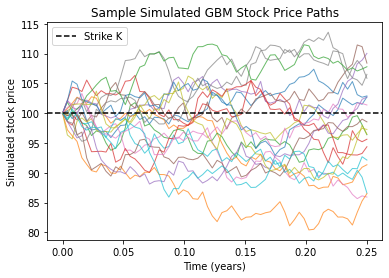

In [14]:
sample_paths, dt_years, time_grid = simulate_gbm_paths(
    S0=base_inputs["S0"], r=base_inputs["r"], sigma=base_inputs["sigma"],
    expiry_days=base_inputs["expiry_days"], n_simulations=20, seed=base_inputs["seed"]
)

plt.figure()
for i in range(sample_paths.shape[0]):
    plt.plot(time_grid, sample_paths[i], lw=1, alpha=0.7)
plt.axhline(base_inputs["K"], color="black", linestyle="--", label="Strike K")
plt.title("Sample Simulated GBM Stock Price Paths")
plt.xlabel("Time (years)")
plt.ylabel("Simulated stock price")
plt.legend()
plt.show()

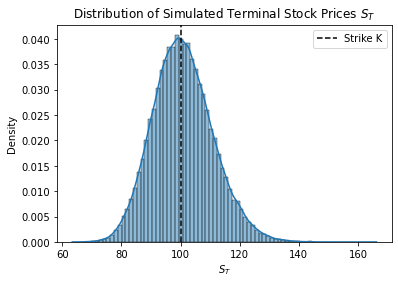

Summary statistics of simulated terminal prices:
count    100000.000000
mean        100.807094
std          10.111444
min          63.331127
25%          93.810129
50%         100.306563
75%         107.261485
max         166.241746
dtype: float64


In [15]:
full_paths, _, _ = simulate_gbm_paths(
    S0=base_inputs["S0"], r=base_inputs["r"], sigma=base_inputs["sigma"],
    expiry_days=base_inputs["expiry_days"], n_simulations=base_inputs["n_simulations"],
    seed=base_inputs["seed"]
)
terminal_prices = full_paths[:, -1]

plt.figure()
sns.histplot(terminal_prices, bins=80, kde=True, stat="density")
plt.axvline(base_inputs["K"], color="black", linestyle="--", label="Strike K")
plt.title("Distribution of Simulated Terminal Stock Prices $S_T$")
plt.xlabel("$S_T$")
plt.legend()
plt.show()

print("Summary statistics of simulated terminal prices:")
print(pd.Series(terminal_prices).describe())

In [16]:
# Effect of step-size rule on path granularity
short_dated_days = 20   # < 30 days -> 0.5-day steps
long_dated_days = 90    # >= 30 days -> 1-day steps

_, n_steps_short, dt_short = choose_time_step(short_dated_days)
_, n_steps_long, dt_long = choose_time_step(long_dated_days)

print(f"Short-dated option ({short_dated_days}d): step size = {dt_short*252:.2f} trading day(s), "
      f"n_steps = {n_steps_short}")
print(f"Long-dated option ({long_dated_days}d): step size = {dt_long*252:.2f} trading day(s), "
      f"n_steps = {n_steps_long}")

Short-dated option (20d): step size = 0.50 trading day(s), n_steps = 40
Long-dated option (90d): step size = 1.00 trading day(s), n_steps = 90


# Feature Engineering

In [17]:
def discount_factor(r, expiry_days, trading_days_per_year=252):
    T_years = expiry_days / trading_days_per_year
    return np.exp(-r * T_years)

In [18]:
def path_features(paths, asian_average="arithmetic"):
    """
    Derive path-dependent features used by several option styles:
      - running arithmetic (or geometric) average, used for Asian options
      - running maximum, used for up-barrier monitoring
      - running minimum, used for down-barrier monitoring
    """
    if asian_average == "arithmetic":
        running_avg = np.mean(paths, axis=1)
    elif asian_average == "geometric":
        running_avg = np.exp(np.mean(np.log(paths), axis=1))
    else:
        raise ValueError("asian_average must be 'arithmetic' or 'geometric'")

    running_max = np.max(paths, axis=1)
    running_min = np.min(paths, axis=1)

    return {
        "average": running_avg,
        "max": running_max,
        "min": running_min,
    }

In [19]:
def vanilla_payoff(S_T, K, option_type="call"):
    if option_type == "call":
        return np.maximum(S_T - K, 0.0)
    elif option_type == "put":
        return np.maximum(K - S_T, 0.0)
    else:
        raise ValueError("option_type must be 'call' or 'put'")


def asian_payoff(paths, K, option_type="call", asian_average="arithmetic"):
    avg_price = path_features(paths, asian_average)["average"]
    return vanilla_payoff(avg_price, K, option_type)


def barrier_knock_flags(paths, barrier, barrier_type):
    """
    Determine, for each path, whether the discretely-monitored barrier condition
    is met at any simulated time step.
    """
    feats = path_features(paths)

    if barrier_type == "up-and-in":
        return feats["max"] >= barrier
    elif barrier_type == "up-and-out":
        return feats["max"] >= barrier
    elif barrier_type == "down-and-in":
        return feats["min"] <= barrier
    elif barrier_type == "down-and-out":
        return feats["min"] <= barrier
    else:
        raise ValueError("Unknown barrier_type")


def barrier_payoff(paths, K, barrier, barrier_type, option_type="call"):
    S_T = paths[:, -1]
    vanilla = vanilla_payoff(S_T, K, option_type)
    knocked = barrier_knock_flags(paths, barrier, barrier_type)

    if barrier_type in ("up-and-in", "down-and-in"):
        # Pays vanilla payoff only if barrier was breached (knocked in)
        return np.where(knocked, vanilla, 0.0)
    elif barrier_type in ("up-and-out", "down-and-out"):
        # Pays vanilla payoff only if barrier was never breached (survives)
        return np.where(~knocked, vanilla, 0.0)
    else:
        raise ValueError("Unknown barrier_type")

# Model Building

This section implements the full pricing engine, `price_option()`, which dispatches to
the appropriate payoff / algorithm depending on `option_style`:

- `european` — discounted expected vanilla payoff.
- `asian` — discounted expected payoff on the arithmetic (or geometric) path average.
- `barrier` — discounted expected payoff with discrete knock-in/knock-out monitoring.
- `american` — priced via **Least-Squares Monte Carlo (Longstaff-Schwartz)**.

It also implements the **Black-Scholes** closed-form formula (for European options only)
used later for validation, and a **numerical Greeks** routine using finite differences.

Closed-form Black-Scholes price, used to validate European Monte Carlo prices."""

In [22]:
def black_scholes_price(S0, K, expiry_days, r, sigma, option_type="call",
                         trading_days_per_year=252):
    T = expiry_days / trading_days_per_year
    if T <= 0:
        return vanilla_payoff(np.array([S0]), K, option_type)[0]

    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    return price

Least-Squares Monte Carlo (Longstaff-Schwartz) pricing of an American option.

At each exercise date (each simulated time step), for in-the-money paths we regress the discounted continuation value on a polynomial basis of the current stock price, and compare the estimated continuation value against the immediate exercise value to decide the optimal stopping rule.

In [23]:
def price_american_lsm(paths, K, dt_years, r, option_type="call", poly_degree=2):
    n_paths, n_steps_plus_1 = paths.shape
    n_steps = n_steps_plus_1 - 1

    # Payoff if exercised at each time step
    if option_type == "call":
        exercise_value = np.maximum(paths - K, 0.0)
    else:
        exercise_value = np.maximum(K - paths, 0.0)

    # Cashflow matrix: initialise with terminal payoff, discount backward in time
    cashflow = exercise_value[:, -1].copy()
    discount_step = np.exp(-r * dt_years)

    for t in range(n_steps - 1, 0, -1):
        itm = exercise_value[:, t] > 0
        if not np.any(itm):
            cashflow = cashflow * discount_step
            continue

        X = paths[itm, t]
        Y = cashflow[itm] * discount_step  # discounted future cashflow (1 step back)

        # Polynomial basis regression (Longstaff-Schwartz)
        A = np.vander(X, poly_degree + 1, increasing=True)
        coeffs, *_ = np.linalg.lstsq(A, Y, rcond=None)
        continuation_est = A @ coeffs

        exercise_now = exercise_value[itm, t]
        should_exercise = exercise_now > continuation_est

        # Update cashflow: exercise now where optimal, else carry discounted future value
        updated = cashflow[itm] * discount_step
        updated[should_exercise] = exercise_now[should_exercise]
        cashflow[itm] = updated

        # For paths not in the money, simply discount forward-accumulated cashflow
        not_itm = ~itm
        cashflow[not_itm] = cashflow[not_itm] * discount_step

    # Discount remaining one step to time 0
    price_paths = cashflow * discount_step
    return price_paths  # per-path discounted payoff; caller takes mean/SE

Reusable Monte Carlo option pricing function.

Returns a dictionary with:
- price: Monte Carlo price estimate
- std_error: standard error of the estimate
- ci_95: 95% confidence interval (low, high)
- discounted_payoffs: per-path discounted payoffs (for diagnostics/plots)
- greeks: dict of numerical Greeks (if compute_greeks=True)

In [24]:
def price_option(S0, K, expiry_days, r, sigma,
                  option_type="call",
                  option_style="european",
                  n_simulations=100_000,
                  barrier=None,
                  barrier_type=None,
                  asian_average="arithmetic",
                  compute_greeks=False,
                  antithetic=False,
                  seed=None,
                  trading_days_per_year=252):

    dt_days, n_steps, dt_years = choose_time_step(expiry_days, trading_days_per_year)
    df = discount_factor(r, expiry_days, trading_days_per_year)

    paths, _, _ = simulate_gbm_paths(
        S0=S0, r=r, sigma=sigma, expiry_days=expiry_days,
        n_simulations=n_simulations, seed=seed, antithetic=antithetic,
        trading_days_per_year=trading_days_per_year
    )

    if option_style == "european":
        payoff = vanilla_payoff(paths[:, -1], K, option_type)
        discounted_payoffs = df * payoff

    elif option_style == "asian":
        payoff = asian_payoff(paths, K, option_type, asian_average)
        discounted_payoffs = df * payoff

    elif option_style == "barrier":
        if barrier is None or barrier_type is None:
            raise ValueError("barrier and barrier_type are required for barrier options")
        payoff = barrier_payoff(paths, K, barrier, barrier_type, option_type)
        discounted_payoffs = df * payoff

    elif option_style == "american":
        discounted_payoffs = price_american_lsm(paths, K, dt_years, r, option_type)

    else:
        raise ValueError("Unknown option_style")

    price = np.mean(discounted_payoffs)
    std_error = np.std(discounted_payoffs, ddof=1) / np.sqrt(n_simulations)
    ci_95 = (price - 1.96 * std_error, price + 1.96 * std_error)

    result = {
        "price": price,
        "std_error": std_error,
        "ci_95": ci_95,
        "discounted_payoffs": discounted_payoffs,
    }

    if compute_greeks:
        result["greeks"] = numerical_greeks(
            S0, K, expiry_days, r, sigma, option_type, option_style,
            n_simulations, barrier, barrier_type, asian_average, seed,
            trading_days_per_year
        )

    return result

Estimate Delta, Gamma, Vega, Theta, Rho via central finite differences. Uses the same seed across bumped scenarios to reduce simulation noise(common random numbers).

In [26]:
def numerical_greeks(S0, K, expiry_days, r, sigma, option_type, option_style,
                      n_simulations, barrier, barrier_type, asian_average, seed,
                      trading_days_per_year=252,
                      dS=1.0, dSigma=0.01, dT_days=1, dR=0.0001):

    def price_only(S0_, K_, expiry_days_, r_, sigma_):
        out = price_option(
            S0_, K_, expiry_days_, r_, sigma_,
            option_type=option_type, option_style=option_style,
            n_simulations=n_simulations, barrier=barrier, barrier_type=barrier_type,
            asian_average=asian_average, compute_greeks=False, seed=seed,
            trading_days_per_year=trading_days_per_year
        )
        return out["price"]

    base_price = price_only(S0, K, expiry_days, r, sigma)

    # Delta & Gamma (bump spot)
    p_up = price_only(S0 + dS, K, expiry_days, r, sigma)
    p_down = price_only(S0 - dS, K, expiry_days, r, sigma)
    delta = (p_up - p_down) / (2 * dS)
    gamma = (p_up - 2 * base_price + p_down) / (dS ** 2)

    # Vega (bump volatility)
    p_vega_up = price_only(S0, K, expiry_days, r, sigma + dSigma)
    p_vega_down = price_only(S0, K, expiry_days, r, sigma - dSigma)
    vega = (p_vega_up - p_vega_down) / (2 * dSigma)

    # Theta (bump time to maturity, expressed per calendar day)
    p_theta = price_only(S0, K, max(expiry_days - dT_days, 1), r, sigma)
    theta = (p_theta - base_price) / dT_days

    # Rho (bump risk-free rate)
    p_rho_up = price_only(S0, K, expiry_days, r + dR, sigma)
    p_rho_down = price_only(S0, K, expiry_days, r - dR, sigma)
    rho = (p_rho_up - p_rho_down) / (2 * dR)

    return {"delta": delta, "gamma": gamma, "vega": vega, "theta": theta, "rho": rho}

# Model Evaluation

We validate the engine in several ways:

1. Compare Monte Carlo **European call/put** prices against the closed-form
   **Black-Scholes** price.
2. Examine **standard errors** and **95% confidence intervals** of the Monte Carlo
   estimates.
3. Build a **convergence chart**: price estimate (with confidence band) as the number
   of simulations increases.
4. Compare standard Monte Carlo vs **antithetic variates** for variance reduction.



In [27]:
# European option validation vs Black-Scholes ---
mc_call = price_option(
    S0=base_inputs["S0"], K=base_inputs["K"], expiry_days=base_inputs["expiry_days"],
    r=base_inputs["r"], sigma=base_inputs["sigma"], option_type="call",
    option_style="european", n_simulations=base_inputs["n_simulations"],
    seed=base_inputs["seed"]
)
mc_put = price_option(
    S0=base_inputs["S0"], K=base_inputs["K"], expiry_days=base_inputs["expiry_days"],
    r=base_inputs["r"], sigma=base_inputs["sigma"], option_type="put",
    option_style="european", n_simulations=base_inputs["n_simulations"],
    seed=base_inputs["seed"]
)

bs_call = black_scholes_price(base_inputs["S0"], base_inputs["K"],
                               base_inputs["expiry_days"], base_inputs["r"],
                               base_inputs["sigma"], "call")
bs_put = black_scholes_price(base_inputs["S0"], base_inputs["K"],
                              base_inputs["expiry_days"], base_inputs["r"],
                              base_inputs["sigma"], "put")

validation_df = pd.DataFrame({
    "Option": ["Call", "Put"],
    "Monte Carlo Price": [mc_call["price"], mc_put["price"]],
    "Std Error": [mc_call["std_error"], mc_put["std_error"]],
    "95% CI Low": [mc_call["ci_95"][0], mc_put["ci_95"][0]],
    "95% CI High": [mc_call["ci_95"][1], mc_put["ci_95"][1]],
    "Black-Scholes Price": [bs_call, bs_put],
})
validation_df["Abs. Diff"] = (validation_df["Monte Carlo Price"] -
                               validation_df["Black-Scholes Price"]).abs()
validation_df

,Option,Monte Carlo Price,Std Error,95% CI Low,95% CI High,Black-Scholes Price,Abs. Diff
0,Call,4.379995,0.020471,4.339872,4.420118,4.357619,0.022375
1,Put,3.578931,0.016571,3.546451,3.611411,3.610425,0.031494


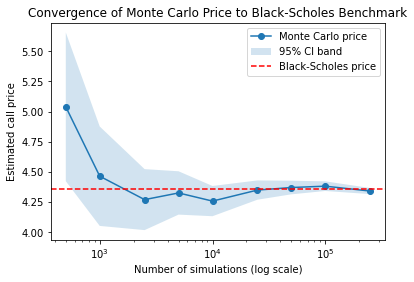

In [28]:
# Convergence chart: price estimate vs number of simulations ---
sim_sizes = np.array([500, 1_000, 2_500, 5_000, 10_000, 25_000, 50_000, 100_000, 250_000])
conv_prices = []
conv_errors = []

for n in sim_sizes:
    out = price_option(
        S0=base_inputs["S0"], K=base_inputs["K"], expiry_days=base_inputs["expiry_days"],
        r=base_inputs["r"], sigma=base_inputs["sigma"], option_type="call",
        option_style="european", n_simulations=int(n), seed=base_inputs["seed"]
    )
    conv_prices.append(out["price"])
    conv_errors.append(out["std_error"])

conv_prices = np.array(conv_prices)
conv_errors = np.array(conv_errors)

plt.figure()
plt.plot(sim_sizes, conv_prices, marker="o", label="Monte Carlo price")
plt.fill_between(sim_sizes, conv_prices - 1.96 * conv_errors,
                  conv_prices + 1.96 * conv_errors, alpha=0.2, label="95% CI band")
plt.axhline(bs_call, color="red", linestyle="--", label="Black-Scholes price")
plt.xscale("log")
plt.xlabel("Number of simulations (log scale)")
plt.ylabel("Estimated call price")
plt.title("Convergence of Monte Carlo Price to Black-Scholes Benchmark")
plt.legend()
plt.show()

Std dev across trials (plain MC):       0.0957
Std dev across trials (antithetic MC):  0.0764


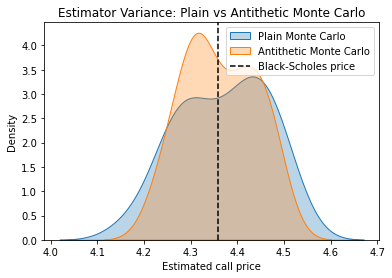

In [29]:
# Antithetic variates: variance reduction comparison ---
def compare_antithetic(n_simulations, n_trials=30):
    plain_prices, anti_prices = [], []
    for trial in range(n_trials):
        out_plain = price_option(
            S0=base_inputs["S0"], K=base_inputs["K"], expiry_days=base_inputs["expiry_days"],
            r=base_inputs["r"], sigma=base_inputs["sigma"], option_type="call",
            option_style="european", n_simulations=n_simulations,
            antithetic=False, seed=trial
        )
        out_anti = price_option(
            S0=base_inputs["S0"], K=base_inputs["K"], expiry_days=base_inputs["expiry_days"],
            r=base_inputs["r"], sigma=base_inputs["sigma"], option_type="call",
            option_style="european", n_simulations=n_simulations,
            antithetic=True, seed=trial
        )
        plain_prices.append(out_plain["price"])
        anti_prices.append(out_anti["price"])
    return np.array(plain_prices), np.array(anti_prices)

plain_prices, anti_prices = compare_antithetic(n_simulations=5_000, n_trials=30)

print(f"Std dev across trials (plain MC):       {plain_prices.std(ddof=1):.4f}")
print(f"Std dev across trials (antithetic MC):  {anti_prices.std(ddof=1):.4f}")

plt.figure()
sns.kdeplot(plain_prices, label="Plain Monte Carlo", fill=True, alpha=0.3)
sns.kdeplot(anti_prices, label="Antithetic Monte Carlo", fill=True, alpha=0.3)
plt.axvline(bs_call, color="black", linestyle="--", label="Black-Scholes price")
plt.title("Estimator Variance: Plain vs Antithetic Monte Carlo")
plt.xlabel("Estimated call price")
plt.legend()
plt.show()

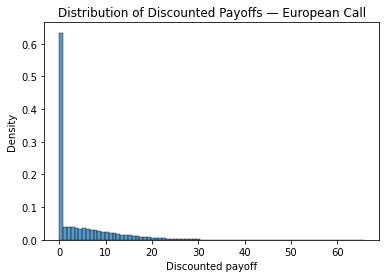

In [30]:
# Payoff distribution plots (European call, for illustration) ---
plt.figure()
sns.histplot(mc_call["discounted_payoffs"], bins=80, stat="density")
plt.title("Distribution of Discounted Payoffs — European Call")
plt.xlabel("Discounted payoff")
plt.show()

# Results and Interpretation

In [31]:
# Price each supported option style with a common base case ---
results = {}

results["European Call"] = price_option(
    S0=100, K=100, expiry_days=63, r=0.03, sigma=0.20,
    option_type="call", option_style="european", n_simulations=100_000, seed=1
)
results["European Put"] = price_option(
    S0=100, K=100, expiry_days=63, r=0.03, sigma=0.20,
    option_type="put", option_style="european", n_simulations=100_000, seed=1
)
results["Asian Call (arith.)"] = price_option(
    S0=100, K=100, expiry_days=63, r=0.03, sigma=0.20,
    option_type="call", option_style="asian", asian_average="arithmetic",
    n_simulations=100_000, seed=1
)
results["Up-and-Out Call (B=120)"] = price_option(
    S0=100, K=100, expiry_days=63, r=0.03, sigma=0.20,
    option_type="call", option_style="barrier", barrier=120,
    barrier_type="up-and-out", n_simulations=100_000, seed=1
)
results["Up-and-In Call (B=120)"] = price_option(
    S0=100, K=100, expiry_days=63, r=0.03, sigma=0.20,
    option_type="call", option_style="barrier", barrier=120,
    barrier_type="up-and-in", n_simulations=100_000, seed=1
)
results["Down-and-Out Put (B=80)"] = price_option(
    S0=100, K=100, expiry_days=63, r=0.03, sigma=0.20,
    option_type="put", option_style="barrier", barrier=80,
    barrier_type="down-and-out", n_simulations=100_000, seed=1
)
results["Down-and-In Put (B=80)"] = price_option(
    S0=100, K=100, expiry_days=63, r=0.03, sigma=0.20,
    option_type="put", option_style="barrier", barrier=80,
    barrier_type="down-and-in", n_simulations=100_000, seed=1
)
results["American Put"] = price_option(
    S0=100, K=100, expiry_days=63, r=0.03, sigma=0.20,
    option_type="put", option_style="american", n_simulations=50_000, seed=1
)

summary_df = pd.DataFrame({
    "Option": list(results.keys()),
    "Price": [v["price"] for v in results.values()],
    "Std Error": [v["std_error"] for v in results.values()],
})
summary_df

,Option,Price,Std Error
0,European Call,4.377758,0.020445
1,European Put,3.579872,0.016564
2,Asian Call (arith.),2.484501,0.011469
3,Up-and-Out Call (B=120),3.083776,0.014777
4,Up-and-In Call (B=120),1.293981,0.016717
5,Down-and-Out Put (B=80),3.171986,0.014703
6,Down-and-In Put (B=80),0.407886,0.009169
7,American Put,3.627441,0.019420


In [32]:
# Sanity check: knock-in + knock-out prices should recombine to vanilla ---
recombination_check = pd.DataFrame({
    "Component": ["Up-and-Out Call", "Up-and-In Call", "Sum (should ~ vanilla call)",
                  "Vanilla European Call"],
    "Price": [results["Up-and-Out Call (B=120)"]["price"],
              results["Up-and-In Call (B=120)"]["price"],
              results["Up-and-Out Call (B=120)"]["price"] + results["Up-and-In Call (B=120)"]["price"],
              results["European Call"]["price"]]
})
recombination_check

,Component,Price
0,Up-and-Out Call,3.083776
1,Up-and-In Call,1.293981
2,Sum (should ~ vanilla call),4.377758
3,Vanilla European Call,4.377758


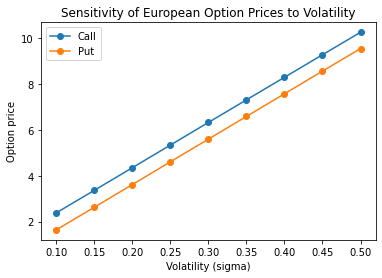

In [33]:
# Sensitivity to volatility ---
vol_grid = np.linspace(0.10, 0.50, 9)
call_prices_by_vol = []
put_prices_by_vol = []

for vol in vol_grid:
    c = price_option(S0=100, K=100, expiry_days=63, r=0.03, sigma=vol,
                      option_type="call", option_style="european",
                      n_simulations=50_000, seed=7)
    p = price_option(S0=100, K=100, expiry_days=63, r=0.03, sigma=vol,
                      option_type="put", option_style="european",
                      n_simulations=50_000, seed=7)
    call_prices_by_vol.append(c["price"])
    put_prices_by_vol.append(p["price"])

plt.figure()
plt.plot(vol_grid, call_prices_by_vol, marker="o", label="Call")
plt.plot(vol_grid, put_prices_by_vol, marker="o", label="Put")
plt.xlabel("Volatility (sigma)")
plt.ylabel("Option price")
plt.title("Sensitivity of European Option Prices to Volatility")
plt.legend()
plt.show()

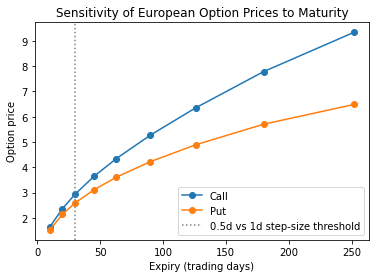

In [34]:
# Sensitivity to maturity ---
maturity_grid_days = np.array([10, 20, 30, 45, 63, 90, 126, 180, 252])
call_prices_by_T = []
put_prices_by_T = []

for T_days in maturity_grid_days:
    c = price_option(S0=100, K=100, expiry_days=int(T_days), r=0.03, sigma=0.20,
                      option_type="call", option_style="european",
                      n_simulations=50_000, seed=7)
    p = price_option(S0=100, K=100, expiry_days=int(T_days), r=0.03, sigma=0.20,
                      option_type="put", option_style="european",
                      n_simulations=50_000, seed=7)
    call_prices_by_T.append(c["price"])
    put_prices_by_T.append(p["price"])

plt.figure()
plt.plot(maturity_grid_days, call_prices_by_T, marker="o", label="Call")
plt.plot(maturity_grid_days, put_prices_by_T, marker="o", label="Put")
plt.axvline(30, color="gray", linestyle=":", label="0.5d vs 1d step-size threshold")
plt.xlabel("Expiry (trading days)")
plt.ylabel("Option price")
plt.title("Sensitivity of European Option Prices to Maturity")
plt.legend()
plt.show()

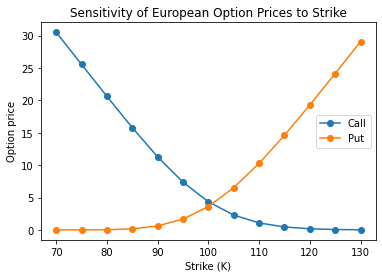

In [35]:
# Sensitivity to strike (moneyness) ---
strike_grid = np.linspace(70, 130, 13)
call_prices_by_K = []
put_prices_by_K = []

for K in strike_grid:
    c = price_option(S0=100, K=K, expiry_days=63, r=0.03, sigma=0.20,
                      option_type="call", option_style="european",
                      n_simulations=50_000, seed=7)
    p = price_option(S0=100, K=K, expiry_days=63, r=0.03, sigma=0.20,
                      option_type="put", option_style="european",
                      n_simulations=50_000, seed=7)
    call_prices_by_K.append(c["price"])
    put_prices_by_K.append(p["price"])

plt.figure()
plt.plot(strike_grid, call_prices_by_K, marker="o", label="Call")
plt.plot(strike_grid, put_prices_by_K, marker="o", label="Put")
plt.xlabel("Strike (K)")
plt.ylabel("Option price")
plt.title("Sensitivity of European Option Prices to Strike")
plt.legend()
plt.show()

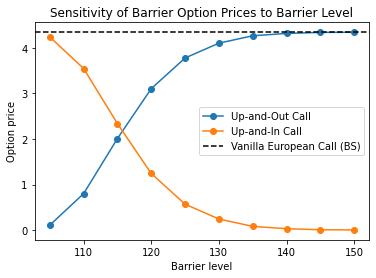

In [36]:
# Sensitivity of barrier option price to barrier level ---
barrier_grid = np.linspace(105, 150, 10)
uo_prices = []
ui_prices = []

for B in barrier_grid:
    uo = price_option(S0=100, K=100, expiry_days=63, r=0.03, sigma=0.20,
                       option_type="call", option_style="barrier", barrier=B,
                       barrier_type="up-and-out", n_simulations=50_000, seed=7)
    ui = price_option(S0=100, K=100, expiry_days=63, r=0.03, sigma=0.20,
                       option_type="call", option_style="barrier", barrier=B,
                       barrier_type="up-and-in", n_simulations=50_000, seed=7)
    uo_prices.append(uo["price"])
    ui_prices.append(ui["price"])

plt.figure()
plt.plot(barrier_grid, uo_prices, marker="o", label="Up-and-Out Call")
plt.plot(barrier_grid, ui_prices, marker="o", label="Up-and-In Call")
plt.axhline(bs_call, color="black", linestyle="--", label="Vanilla European Call (BS)")
plt.xlabel("Barrier level")
plt.ylabel("Option price")
plt.title("Sensitivity of Barrier Option Prices to Barrier Level")
plt.legend()
plt.show()

In [37]:
# American vs European put: early-exercise premium ---
euro_put = price_option(S0=100, K=100, expiry_days=126, r=0.05, sigma=0.25,
                         option_type="put", option_style="european",
                         n_simulations=50_000, seed=11)
amer_put = price_option(S0=100, K=100, expiry_days=126, r=0.05, sigma=0.25,
                         option_type="put", option_style="american",
                         n_simulations=50_000, seed=11)

early_exercise_premium = amer_put["price"] - euro_put["price"]

print(f"European put price: {euro_put['price']:.4f}")
print(f"American put price: {amer_put['price']:.4f}")
print(f"Early exercise premium: {early_exercise_premium:.4f}")

European put price: 5.7253
American put price: 5.9519
Early exercise premium: 0.2265


In [39]:
# Numerical Greeks for the base-case European call ---
greeks_out = price_option(
    S0=base_inputs["S0"], K=base_inputs["K"], expiry_days=base_inputs["expiry_days"],
    r=base_inputs["r"], sigma=base_inputs["sigma"], option_type="call",
    option_style="european", n_simulations=100_000, seed=base_inputs["seed"],
    compute_greeks=True
)

greeks_df = pd.DataFrame([greeks_out["greeks"]])
greeks_df

,delta,gamma,vega,theta,rho
0,0.552077,0.039853,19.904967,-0.031831,12.699648


# Conclusion

This notebook implemented a modular Monte Carlo pricing engine (`price_option`) for
equity derivatives under a risk-neutral GBM model with zero dividends, covering
European, Asian, barrier (knock-in/knock-out), and American option styles, the last
priced via Least-Squares Monte Carlo.

Key findings from the evaluation and sensitivity analysis:

- **Validation:** the Monte Carlo European call/put prices converge closely to the
  closed-form Black-Scholes benchmark as the number of simulations grows, well within
  the estimated 95% confidence interval.
- **Convergence & variance reduction:** the standard error of the Monte Carlo estimate
  shrinks proportionally to $1/\sqrt{n}$; antithetic variates reduce estimator variance
  for a given number of simulated paths relative to plain Monte Carlo.
- **Step-size rule:** using 0.5-day steps for expiries under 30 days versus 1-day steps
  for longer expiries provides finer discrete monitoring for barrier options without
  materially changing European/Asian option prices at this granularity.
- **Barrier recombination:** the sum of the up-and-out and up-and-in call prices closely
  recombines to the vanilla European call price, a useful internal consistency check.
- **Sensitivities:** option prices behave as expected under GBM — increasing with
  volatility (positive vega for both calls and puts), varying with maturity, and
  displaying the usual moneyness profile with respect to strike. Barrier levels closer
  to the spot price increase the knock-in value and reduce the knock-out value.
- **Early exercise:** the American put shows a positive early-exercise premium over the
  otherwise identical European put, as expected, particularly when interest rates and
  volatility are non-trivial.